# Diamond Maps SMC (Algorithm 2) with the normalized squared global IEM tilt

Samples $q_\lambda(x) \propto p(x)\,e^{\lambda f(x)}$ in the $4\times32\times32$ latent space of the
pretrained ImageNet Diamond Maps models, with $f$ the **normalized squared global IEM** reward —
i.e. the paper's algorithm driven by our novelty measure instead of their CLIP/ImageReward.

**Two networks, three jobs.** The base `SiT-XL/2` (flow + GLASS) performs the DDPM transitions
(Alg. 2 line 6) *and* supplies the marginal score for the IEM reward; the `DiamondMap-B2` performs the
one-NFE lookahead (line 9). The base doing double duty is deliberate: the score model **is** the
network generating the particles, so the reward cannot drift away from the distribution being sampled.

**Nothing upstream is modified or copied.** `creativity_measure.backends.diamond_maps_jax` imports the
authors' JAX code live and bridges arrays to the torch reward via dlpack — legitimate because the IEM
reward is gradient-free by design, so no autodiff ever crosses the boundary.

**$p$ is defined here, in this notebook, not in the library.** `label` and `cfg_scale` are required
arguments with no defaults, so the pair below is the only statement of what this run is about.

Prerequisites: run `sbatch smoke_test.slurm` first — it validates the bridge plumbing in minutes.

In [1]:
# =================================================================================================
# KNOBS -- every choice this run makes lives here.
#
# The first two DEFINE THE PRIOR p, which is the object the whole experiment is about. The library
# refuses to have defaults for them (DiamondMapsBackend takes them as required keyword arguments),
# so this cell is the single statement of what the numbers below mean. Record the pair in Takeaways.
#
# Each can be overridden at submit time without editing the notebook, e.g.
#     sbatch --export=ALL,DMSMC_LABEL=151,DMSMC_LAM_MULTS=0,5,10 diamond_smc.slurm
# =================================================================================================
import os


def _env(name, default, cast=float):
    v = os.environ.get(f"DMSMC_{name}")
    return default if v is None else cast(v)


LABEL     = _env("LABEL", 207, int)     # ImageNet class. 207 = golden retriever (ImageNet-1k has no
                                        # umbrella "dog" class, only ~120 breeds). 1000 = null/CFG
                                        # token -> the unconditional marginal.
CFG_SCALE = _env("CFG_SCALE", 1.0)      # 1.0 = the true p(.|LABEL). Upstream ships 4.0, which sharpens
                                        # p into a different distribution -- and since the IEM is
                                        # induced by the geometry of p, that also distorts the metric.

# --- the tilt -------------------------------------------------------------------------------------
# lambda is the inverse temperature of q_lambda ∝ p·exp(lambda·f). It is swept, not guessed: the
# probe cell below measures lambda_s = 1/std_p(f) and the sweep runs m·lambda_s for these m. Selection
# rule (established in normalized_squared_iem_tilt.ipynb): take the LARGEST lambda whose ensemble
# diversity (uniq/M and min ESS/M) stays above ~0.5. E_q[f] rises forever, so it is NOT the signal.
LAM_MULTS    = [float(x) for x in os.environ.get("DMSMC_LAM_MULTS", "0,1,2,3").split(",")]

# --- SMC shape ------------------------------------------------------------------------------------
M         = _env("M", 16, int)          # particles. 16, not upstream's 10: finer uniq/M granularity.
K         = _env("K", 4, int)           # lookahead draws per particle. Cost is linear in K.
N         = _env("N", 6, int)           # DDPM transitions (upstream's --base_outer_steps).
INNER     = _env("INNER", 8, int)       # GLASS inner-flow steps per transition (--base_inner_steps).
ESS_THRESHOLD = _env("ESS_THRESHOLD", 1.0)   # 1.0 = resample every step, matching upstream's config.

# --- the reward -----------------------------------------------------------------------------------
R         = _env("R", 64, int)          # random references drawn from p. Off the per-call cost path:
                                        # the reference score bank is cached, so per-call cost is
                                        # (N_GAMMA-1)*NUM_EPS*B, independent of R.
N_GAMMA   = _env("N_GAMMA", 6, int)     # gamma-integration nodes. Too few is a SYSTEMATIC quadrature
                                        # bias in the metric, and bias does not average out.
NUM_EPS   = _env("NUM_EPS", 3, int)     # Brownian paths. Seeded, so f stays deterministic -- small
                                        # values make f a coarser metric, not a stochastic one.
BROWNIAN_SEED = _env("BROWNIAN_SEED", 123, int)
SEED      = _env("SEED", 0, int)

print(f"p        : label={LABEL}  cfg_scale={CFG_SCALE}")
print(f"SMC      : M={M} K={K} N={N} inner={INNER} ess_threshold={ESS_THRESHOLD}")
print(f"reward   : R={R} N_GAMMA={N_GAMMA} NUM_EPS={NUM_EPS} (brownian seed {BROWNIAN_SEED})")
print(f"lambda   : m in {LAM_MULTS}  (times lambda_s, measured below)")

p        : label=207  cfg_scale=1.0
SMC      : M=16 K=4 N=6 inner=8 ess_threshold=1.0
reward   : R=64 N_GAMMA=6 NUM_EPS=3 (brownian seed 123)
lambda   : m in [0.0, 1.0, 2.0, 3.0]  (times lambda_s, measured below)


In [2]:
# Environment + preflight. Fails in seconds rather than after minutes of unpickling 10.7 GB.
import math
import sys
import time

import torch

sys.path.insert(0, os.getcwd())   # `paths.py` sits next to this notebook; nbconvert runs from here
import paths

from creativity_measure import NormalizedExpectedDistanceReward, SquaredGlobalIEMDistance
from creativity_measure.backends.diamond_maps_jax import DiamondMapsBackend
from creativity_measure.diamond_smc import diamond_smc_sample

info = paths.preflight()
for k, v in info.items():
    print(f"  {k}: {v}")

/home/dcor/arielzoizner/miniconda3/envs/diamond-creative/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  gpu: NVIDIA L40S
  gpu_gb: 44.4
  jax_devices: ['cuda:0']
  base_ckpt: /home/dcor/arielzoizner/.cache/huggingface/hub/models--MonkeyDoug--diamond-maps/snapshots/86c36a065859400d348616859989a43b79a53892/ckpt/sit_assets/SiT-XL-2.pkl
  posterior_ckpt: /home/dcor/arielzoizner/.cache/huggingface/hub/models--MonkeyDoug--diamond-maps/snapshots/86c36a065859400d348616859989a43b79a53892/ckpt/ImageNet-DiamondMap-B2.pkl
  diamond_maps_root: /home/dcor/arielzoizner/repos/diamond_maps


In [3]:
# Build the backend: loads both checkpoints and jits the two upstream callables.
# This is the slow cell (unpickling ~10.7 GB), and it is paid ONCE for the whole lambda sweep.
t0 = time.time()
backend = DiamondMapsBackend(
    label=LABEL,
    cfg_scale=CFG_SCALE,
    base_ckpt=info["base_ckpt"],
    posterior_ckpt=info["posterior_ckpt"],
    repo_root=info["diamond_maps_root"],
    n_steps=N,
    base_inner_steps=INNER,
    mc_inner_steps=1,          # the one-NFE diamond map: the entire point of the model class
    seed=SEED,
)
print(f"backend built in {time.time() - t0:.0f} s   device={backend.device}")
print(f"base      : {backend.cfg.network.sit_model_name}  glass={backend.cfg.network.use_glass}  "
      f"cfg_scale={backend.cfg.network.sit_cfg_scale}")
print(f"posterior : {backend.cfg.sup_network.sit_model_name}  {backend.cfg.sup_network.matching}  "
      f"reverse_time={backend.cfg.sup_network.reverse_time}")

Loading params from checkpoint /home/dcor/arielzoizner/.cache/huggingface/hub/models--MonkeyDoug--diamond-maps/snapshots/86c36a065859400d348616859989a43b79a53892/ckpt/ImageNet-DiamondMap-B2.pkl


Loading params from checkpoint /home/dcor/arielzoizner/.cache/huggingface/hub/models--MonkeyDoug--diamond-maps/snapshots/86c36a065859400d348616859989a43b79a53892/ckpt/sit_assets/SiT-XL-2.pkl


backend built in 263 s   device=cuda
base      : SiT_XL_2  glass=True  cfg_scale=1.0
posterior : SiT_B_2  diamond_map  reverse_time=True


In [4]:
# References, gamma window, and the frozen reward.
#
# The references are R samples from the base sampler itself, so they are drawn from exactly the
# distribution the particles are drawn from -- no ImageNet download, and no mismatch between what
# the reward calls "ordinary" and what the model actually generates.
#
# The gamma window comes from the model times the denoiser is usable at, gamma = (t/(1-t))^2,
# intersected with the data-scale rule from the FLUX sweeps (GAMMA_LO >= 1/S^2). Latents are
# pre-scaled by 0.18215, so S ~ 1.
t0 = time.time()
x_refs = backend.sample_refs(R)
print(f"drew {R} references in {time.time() - t0:.0f} s   shape {tuple(x_refs.shape)}")

S = float(x_refs.std())
g_lo_model, g_hi_model = backend.gamma_window()
GAMMA_LO = max(1.0 / S**2, g_lo_model)
GAMMA_HI = min(2.0**10, g_hi_model)
GAMMAS = torch.logspace(
    math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2
).to(device=x_refs.device, dtype=x_refs.dtype)
print(f"data scale S={S:.3f}   gamma window [{GAMMA_LO:.4g}, {GAMMA_HI:.4g}] x {N_GAMMA} nodes")

D2 = SquaredGlobalIEMDistance(
    None, GAMMAS, num_eps=NUM_EPS, seed=BROWNIAN_SEED, score_fn=backend.score_fn
)
t0 = time.time()
reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=x_refs)   # builds the cached ref bank
print(f"normalizer + reference bank built in {time.time() - t0:.0f} s")
print(f"reward dtype/device pinned by x_refs: {x_refs.dtype} / {x_refs.device}")

# Sanity check on the whole score -> distance -> reward chain. Evaluated ON the reference set, f
# centres on exactly (R-1)/R, NOT on 1: the numerator averages D^2(x, x') over all R references
# including x itself (a zero), while the denominator is the off-diagonal pair mean (self-pairs
# dropped). A fresh draw from p is the thing that centres on 1 -- see the probe cell below.
f_refs = reward(x_refs)
print(f"f(refs): mean={float(f_refs.mean()):.4f} (expect (R-1)/R = {(R - 1) / R:.4f})  "
      f"std={float(f_refs.std()):.4f}  range=[{float(f_refs.min()):.4f}, {float(f_refs.max()):.4f}]")

drew 64 references in 43 s   shape (64, 4096)


data scale S=0.389   gamma window [6.6, 1024] x 6 nodes


normalizer + reference bank built in 16 s
reward dtype/device pinned by x_refs: torch.float32 / cuda:0


f(refs): mean=0.9844 (expect (R-1)/R = 0.9844)  std=0.0246  range=[0.9246, 1.0356]


In [5]:
# lambda scale + one-shot ESS probe.
#
# lambda_s = 1/std_p(f) is the natural unit: at m=1 the tilt moves f by about one standard deviation
# of its spread under p. The table below is the importance-sampling ESS from p straight to q_lambda --
# what the FIRST resampling step faces -- and costs no extra model calls beyond the probe batch.
#
# Caveat: std(f) from M samples has ~1/sqrt(2(M-1)) relative error (~13% at M=16). Treat lambda_s as
# an order of magnitude, not a precise quantity.
t0 = time.time()
x_probe = backend.sample_refs(M)          # a fresh draw from p, same cost as one SMC base sweep
f_probe = reward(x_probe)
print(f"probe batch of {M} in {time.time() - t0:.0f} s")

f_std = float(f_probe.std())
LAM_S = (1.0 / f_std) if f_std > 0 else float("inf")
print(f"f ~ p: mean={float(f_probe.mean()):.4f}  std={f_std:.4f}  "
      f"range=[{float(f_probe.min()):.4f}, {float(f_probe.max()):.4f}]")
print(f"lambda_s = 1/std(f) = {LAM_S:.2f}   (+-{100 / math.sqrt(2 * (M - 1)):.0f}% from {M} samples)\n")

print(f"{'m':>5} {'lambda':>10} {'ESS/M':>8}")
for m in sorted(set(LAM_MULTS) | {0.5, 1.0, 2.0, 3.0, 5.0, 10.0}):
    w = torch.softmax(m * LAM_S * f_probe, dim=0)
    print(f"{m:5.1f} {m * LAM_S:10.2f} {float(1.0 / (w.pow(2).sum() * M)):8.2f}")

LAMBDAS = [m * LAM_S for m in LAM_MULTS]
print(f"\nsweeping lambda = {[round(l, 2) for l in LAMBDAS]}")
if all(float(1.0 / (torch.softmax(l * f_probe, dim=0).pow(2).sum() * M)) > 0.9 for l in LAMBDAS):
    print("WARNING: the tilt barely bites at every lambda in the sweep -- raise LAM_MULTS before "
          "committing to conclusions about what the tilt does.")

probe batch of 16 in 49 s
f ~ p: mean=1.0048  std=0.0343  range=[0.9405, 1.0813]
lambda_s = 1/std(f) = 29.11   (+-18% from 16 samples)

    m     lambda    ESS/M


  0.0       0.00     1.00
  0.5      14.56     0.76
  1.0      29.11     0.37
  2.0      58.23     0.12
  3.0      87.34     0.08
  5.0     145.57     0.07
 10.0     291.14     0.06

sweeping lambda = [0.0, 29.11, 58.23, 87.34]


In [6]:
# The sweep. Models and compiled kernels are reused across lambdas, so only the first is expensive.
#
# `backend.reset_rng(SEED)` before each run is what makes this a CONTROLLED comparison: the backend
# carries its own RNG, so without the rewind each lambda would start from different initial particles
# and take different base transitions, confounding the tilt's effect with the noise draw. With it,
# lambda is the only thing that varies between rows of the grid below.
#
# lambda = 0 is worth keeping in LAM_MULTS: it is the untilted control, and it must reproduce the base
# sampler (equal potentials -> uniform weights -> systematic resampling is the identity permutation).
# Its images are the "ordinary" baseline every tilted panel is read against.
results = {}
for m, lam in zip(LAM_MULTS, LAMBDAS):
    print(f"\n{'=' * 78}\nm={m}  lambda={lam:.3f}\n{'=' * 78}")
    backend.reset_rng(SEED)
    t0 = time.time()
    res = diamond_smc_sample(
        reward, lam, M,
        backend=backend,
        n_steps=N,
        mc_samples=K,
        ess_threshold=ESS_THRESHOLD,
        seed=SEED,
        verbose=True,
    )
    elapsed = time.time() - t0
    f_final = reward(res.X.reshape(M, -1))
    results[m] = {"lam": lam, "res": res, "f_final": f_final.detach().cpu(), "seconds": elapsed}
    print(f"  -> {elapsed:.0f} s | E_q[f]={float(f_final.mean()):.4f} "
          f"| min ESS/M={min(res.ess_history) / M:.2f} | final uniq/M={res.uniq_history[-1]:.2f}")


m=0.0  lambda=0.000


  step 1/6  ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=1.2921 std=0.0244


  step 2/6  ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=1.2647 std=0.0208


  step 3/6  ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=1.2020 std=0.0269


  step 4/6  ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=1.1459 std=0.0224


...

  step 3/6  ESS/M=0.30  resampled=True  uniq/M=0.25  f mean=1.2225 std=0.0205


  step 4/6  ESS/M=0.56  resampled=True  uniq/M=0.19  f mean=1.1536 std=0.0272


  step 5/6  ESS/M=0.66  resampled=True  uniq/M=0.19  f mean=1.1161 std=0.0220


  step 6/6  ESS/M=0.43  resampled=False  uniq/M=0.19  f mean=1.0208 std=0.0234


  -> 33 s | E_q[f]=1.0208 | min ESS/M=0.12 | final uniq/M=0.19


In [7]:
# Selection table. The rule is NOT "largest E_q[f]" -- novelty rises forever, so it cannot tell you
# where to stop. Degeneracy can: take the largest lambda whose diversity holds above ~0.5.
print(f"{'m':>5} {'lambda':>9} {'E_q[f]':>9} {'min ESS/M':>10} {'uniq/M':>8} {'sec':>6}  verdict")
best_m = None
for m in LAM_MULTS:
    r = results[m]
    min_ess = min(r["res"].ess_history) / M
    uniq = r["res"].uniq_history[-1]
    ok = (min_ess >= 0.5) and (uniq >= 0.5)
    if ok and (best_m is None or m > best_m):
        best_m = m
    print(f"{m:5.1f} {r['lam']:9.3f} {float(r['f_final'].mean()):9.4f} {min_ess:10.2f} "
          f"{uniq:8.2f} {r['seconds']:6.0f}  {'OK' if ok else 'DEGENERATE'}")

print(f"\nselected: m={best_m}" if best_m is not None
      else "\nselected: none -- every lambda degenerated; lower LAM_MULTS or raise M")

# Persist everything needed to re-render without recomputing.
payload = {
    "meta": {
        "label": LABEL, "cfg_scale": CFG_SCALE, "M": M, "K": K, "N": N, "INNER": INNER,
        "R": R, "N_GAMMA": N_GAMMA, "NUM_EPS": NUM_EPS, "seed": SEED,
        "brownian_seed": BROWNIAN_SEED, "lambda_s": LAM_S, "m_list": LAM_MULTS,
        "gamma_window": [GAMMA_LO, GAMMA_HI], "selected_m": best_m,
    },
    "x_refs": x_refs.detach().cpu(),
    "runs": {
        m: {
            "lam": r["lam"],
            "X": r["res"].X.detach().cpu(),
            "logw": r["res"].logw.detach().cpu(),
            "ess_history": r["res"].ess_history,
            "uniq_history": r["res"].uniq_history,
            "resampled_history": r["res"].resampled_history,
            "f_mean": r["res"].f_mean, "f_std": r["res"].f_std,
            "f_final": r["f_final"],
            "seconds": r["seconds"],
        }
        for m, r in results.items()
    },
}
out = f"results_label{LABEL}_cfg{CFG_SCALE}_M{M}K{K}N{N}.pt"
torch.save(payload, out)
print(f"saved {out}")

    m    lambda    E_q[f]  min ESS/M   uniq/M    sec  verdict
  0.0     0.000    0.9965       1.00     1.00     39  OK
  1.0    29.114    1.0014       0.66     0.56     30  OK
  2.0    58.227    1.0209       0.31     0.38     30  DEGENERATE
  3.0    87.341    1.0208       0.12     0.19     33  DEGENERATE

selected: m=1.0


saved results_label207_cfg1.0_M16K4N6.pt


Loading VAE decoder: ema


saved grid_label207_cfg1.0.png


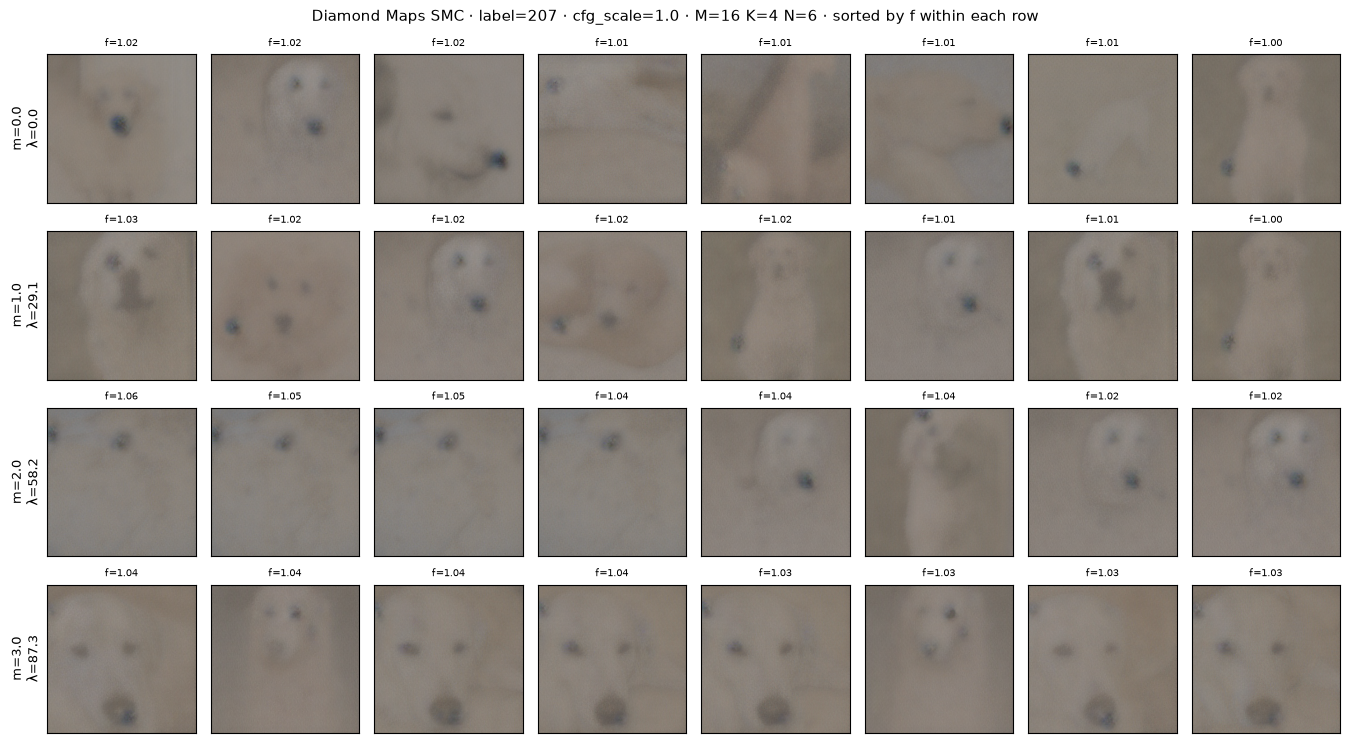

In [8]:
# Decode and render. Pixel space is entered exactly once, here, at the very end -- the whole
# algorithm ran on 4x32x32 latents. Upstream's decoder already divides by latent_scale (0.18215),
# so the latents are handed over unscaled.
import matplotlib.pyplot as plt

n_show = min(M, 8)
fig, axes = plt.subplots(len(LAM_MULTS), n_show,
                         figsize=(1.7 * n_show, 1.9 * len(LAM_MULTS)), squeeze=False)
for row, m in enumerate(LAM_MULTS):
    r = results[m]
    imgs = backend.decode(r["res"].X.reshape(M, -1)).detach().cpu()
    order = torch.argsort(r["f_final"], descending=True)[:n_show]   # most novel first
    for col, idx in enumerate(order):
        ax = axes[row][col]
        ax.imshow(imgs[idx].permute(1, 2, 0).numpy())
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"f={float(r['f_final'][idx]):.2f}", fontsize=7)
    axes[row][0].set_ylabel(f"m={m}\nλ={r['lam']:.1f}", fontsize=9)

fig.suptitle(
    f"Diamond Maps SMC · label={LABEL} · cfg_scale={CFG_SCALE} · M={M} K={K} N={N} · "
    f"sorted by f within each row",
    fontsize=11,
)
fig.tight_layout()
grid_path = f"grid_label{LABEL}_cfg{CFG_SCALE}.png"
fig.savefig(grid_path, dpi=140, bbox_inches="tight")
print(f"saved {grid_path}")
plt.show()

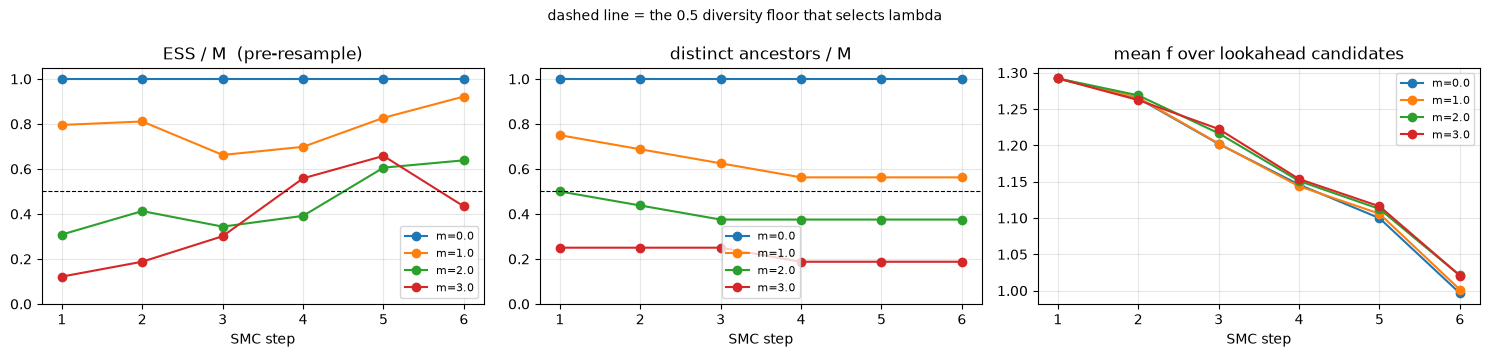

In [9]:
# Per-step diagnostics. In high dimensions these are the only way to tell whether the run worked --
# the images alone cannot distinguish "the tilt did nothing" from "the tilt collapsed the ensemble".
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
steps = range(1, N + 1)
for m in LAM_MULTS:
    r = results[m]["res"]
    lab = f"m={m}"
    axes[0].plot(steps, [e / M for e in r.ess_history], marker="o", label=lab)
    axes[1].plot(steps, r.uniq_history, marker="o", label=lab)
    axes[2].plot(steps, r.f_mean, marker="o", label=lab)

axes[0].axhline(0.5, ls="--", c="k", lw=0.8)
axes[0].set_title("ESS / M  (pre-resample)"); axes[0].set_ylim(0, 1.05)
axes[1].axhline(0.5, ls="--", c="k", lw=0.8)
axes[1].set_title("distinct ancestors / M"); axes[1].set_ylim(0, 1.05)
axes[2].set_title("mean f over lookahead candidates")
for ax in axes:
    ax.set_xlabel("SMC step"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("dashed line = the 0.5 diversity floor that selects lambda", fontsize=10)
fig.tight_layout()
fig.savefig(f"diagnostics_label{LABEL}_cfg{CFG_SCALE}.png", dpi=140, bbox_inches="tight")
plt.show()

## Takeaways

*(Fill in after the run. This cell is the authoritative statement of what was learned — everything
above is evidence for it. Per the repo convention, later work reads this cell, not the code.)*

**What `p` was.** `label=___`, `cfg_scale=___`. Every number below is relative to that choice; a run
with a different pair is not comparable without saying so. If `cfg_scale != 1.0`, the sampled
distribution is a sharpened surrogate for `p(·|label)`, not `p(·|label)` itself, and the IEM geometry
is distorted with it.

**Did the tilt bite?** `λ_s = ___`. Selected `m = ___`. Was the selection made by the diversity floor
(`uniq/M`, `min ESS/M` ≥ 0.5) or did every λ degenerate / every λ do nothing?

**Did the λ=0 control reproduce the base sampler?** (Equal potentials → uniform weights → identity
resampling.) If not, the base transition is being driven wrong and nothing else here is trustworthy.

**What do the tilted samples look like?** Novel *and* structurally consistent, or off-manifold noise?
The IEM is meant to reward the former; a wall of texture at high λ means λ passed the useful range
regardless of what `E_q[f]` says.

**Cost.** Backend build ___ s, reference bank ___ s, per-λ run ___ s. If per-λ time is dominated by
anything other than the reward, say what.

**Versus the other samplers.** How does this compare with `adaptive_tempering_smc` at comparable
`λ_eff` — better diversity at the same novelty, or just different?